# Problem: Detecting an Exoplanet with MCMC (6 points)

Astronomers often detect exoplanets, planets orbiting other stars, by measuring tiny periodic changes in the star’s velocity. These "wobbles" can be modeled statistically as a noisy sinusoid. In this exercise, we’ll approach this problem using Bayesian inference, i.e., our goal is to infer the properties of an exoplanet given noisy data. You do not need to understand the physical meaning of the different parameters of the exoplanet model. The goal of this exercise is purely to understand how Bayesian inference can be used to fit complex models to measured data.

Assuming an exoplanet orbits a star, the radial velocity of the star is given by

$$v(t) = K \sin \left( \frac{2 \pi t}{T} + \phi \right) \, .$$

In the above equation $K > 0$, $t > 0$, and $0 \leq \phi \leq 2 \pi$ are free parameters of the model. ($K$, in turn, depends on the masses of the star and the planet.) In this exercise, we want to infer the posterior of these three quantities from the noisy data provided in `Problem_Set_2_Exoplanets.csv`. This file lists times $t$ and observed radial velocities $v_\mathrm{obs}$. The measured radial velocity equals the true velocity plus a Gaussian noise with a scatter of $\sigma_v = 1.3 \mathrm{m}/\mathrm{s}$. Thus, the total likelihood can be written as

$$\log \mathcal{L}(v_\mathrm{obs} | K, T, \phi) = - \frac{1}{2} \sum\limits_{i=1}^{n} \frac{(v(t_i) - v_{\mathrm{obs}, i})^2}{\sigma_v^2} \, ,$$

where the sum goes over all measurements and their respective times.

(a) Use your MCMC code developed in class to infer posterior distributions for the three parameters. Please assume uniform priors in the ranges $[0, 2 \mathrm{m} / \mathrm{s}]$ for $K$, $[0, 2 \mathrm{years}]$ for $T$ and $[0, 2 \pi]$ for $\phi$. Show trace plots for all three parameters to demonstrate that your results are converged. Run the MCMC for at least $10,000$ steps and discard at least $2,000$ as burn-in.

(b) Visualize the posterior distribution. Specifically, produce three one-dimensional histograms of the individual parameters and three two-dimensional histograms of all possible choices of two parameters, i.e., $K$ vs. $T$, $K$ vs. $\phi$, and $T$ vs. $\phi$.

(c) Repeat exercise (b) using a kernel density estimate (KDE) of your derived posterior instead of the sampled posterior directly. Determine the kernel bandwidth for the KDE using whatever method you think is appropriate but please justify your choice.

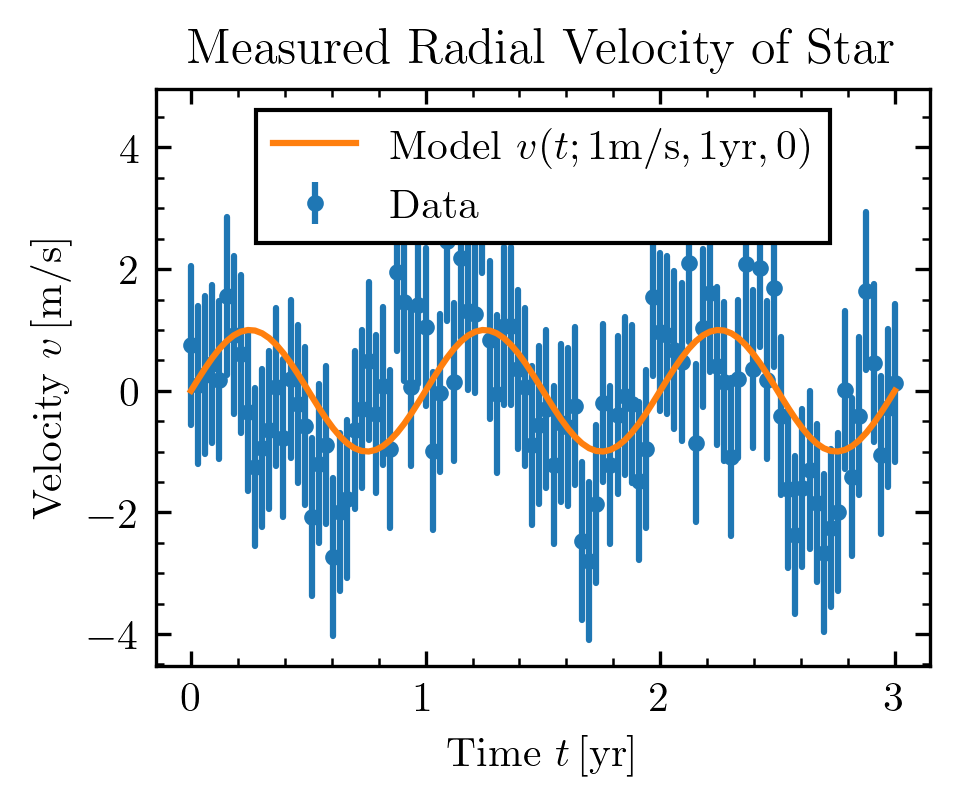

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def v(t, K, T, phi):
    return K * np.sin(2 * np.pi * t / T + phi)


df = pd.read_csv('Problem_Set_2_Exoplanets.csv')
plotline, caps, barlinecols = plt.errorbar(
    df['t'], df['v'], yerr=1.3, fmt='o', ms=3, zorder=0, label='Data')
plt.setp(barlinecols[0], capstyle="round")
K, T, phi = 1, 1, 0
plt.plot(df['t'], v(df['t'], K, T, phi), label=rf'Model $v(t; 1 $m/s$, 1 $yr$, 0)$')
plt.xlabel(r'Time $t \, [\mathrm{yr}]$')
plt.ylabel(r'Velocity $v \, [\mathrm{m} / \mathrm{s}]$')
plt.title("Measured Radial Velocity of Star")
plt.legend(loc='upper center');